## 25.09.04: UNet segmentation model (1st trial run)

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

from tqdm import tqdm
from itertools import pairwise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
from ultralytics import YOLO

from scripts.datasets.calibration import CalibrationDataset
from scripts.datasets.field_masking import MaskingCalibrationDataset
from SoccerNet.Downloader import SoccerNetDownloader

print(f'Torch CUDA availability: {torch.cuda.is_available()}')
print(f'Torch MPS availability: {torch.mps.is_available()}')

Torch CUDA availability: False
Torch MPS availability: True


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
masking_calibration_train_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_valid_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=64,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_test_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=64,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(masking_calibration_train_dataset)}')
print(f'Number of valid samples: {len(masking_calibration_valid_dataset)}')
print(f'Number of test samples: {len(masking_calibration_test_dataset)}')

Number of training samples: 128
Number of valid samples: 64
Number of test samples: 64


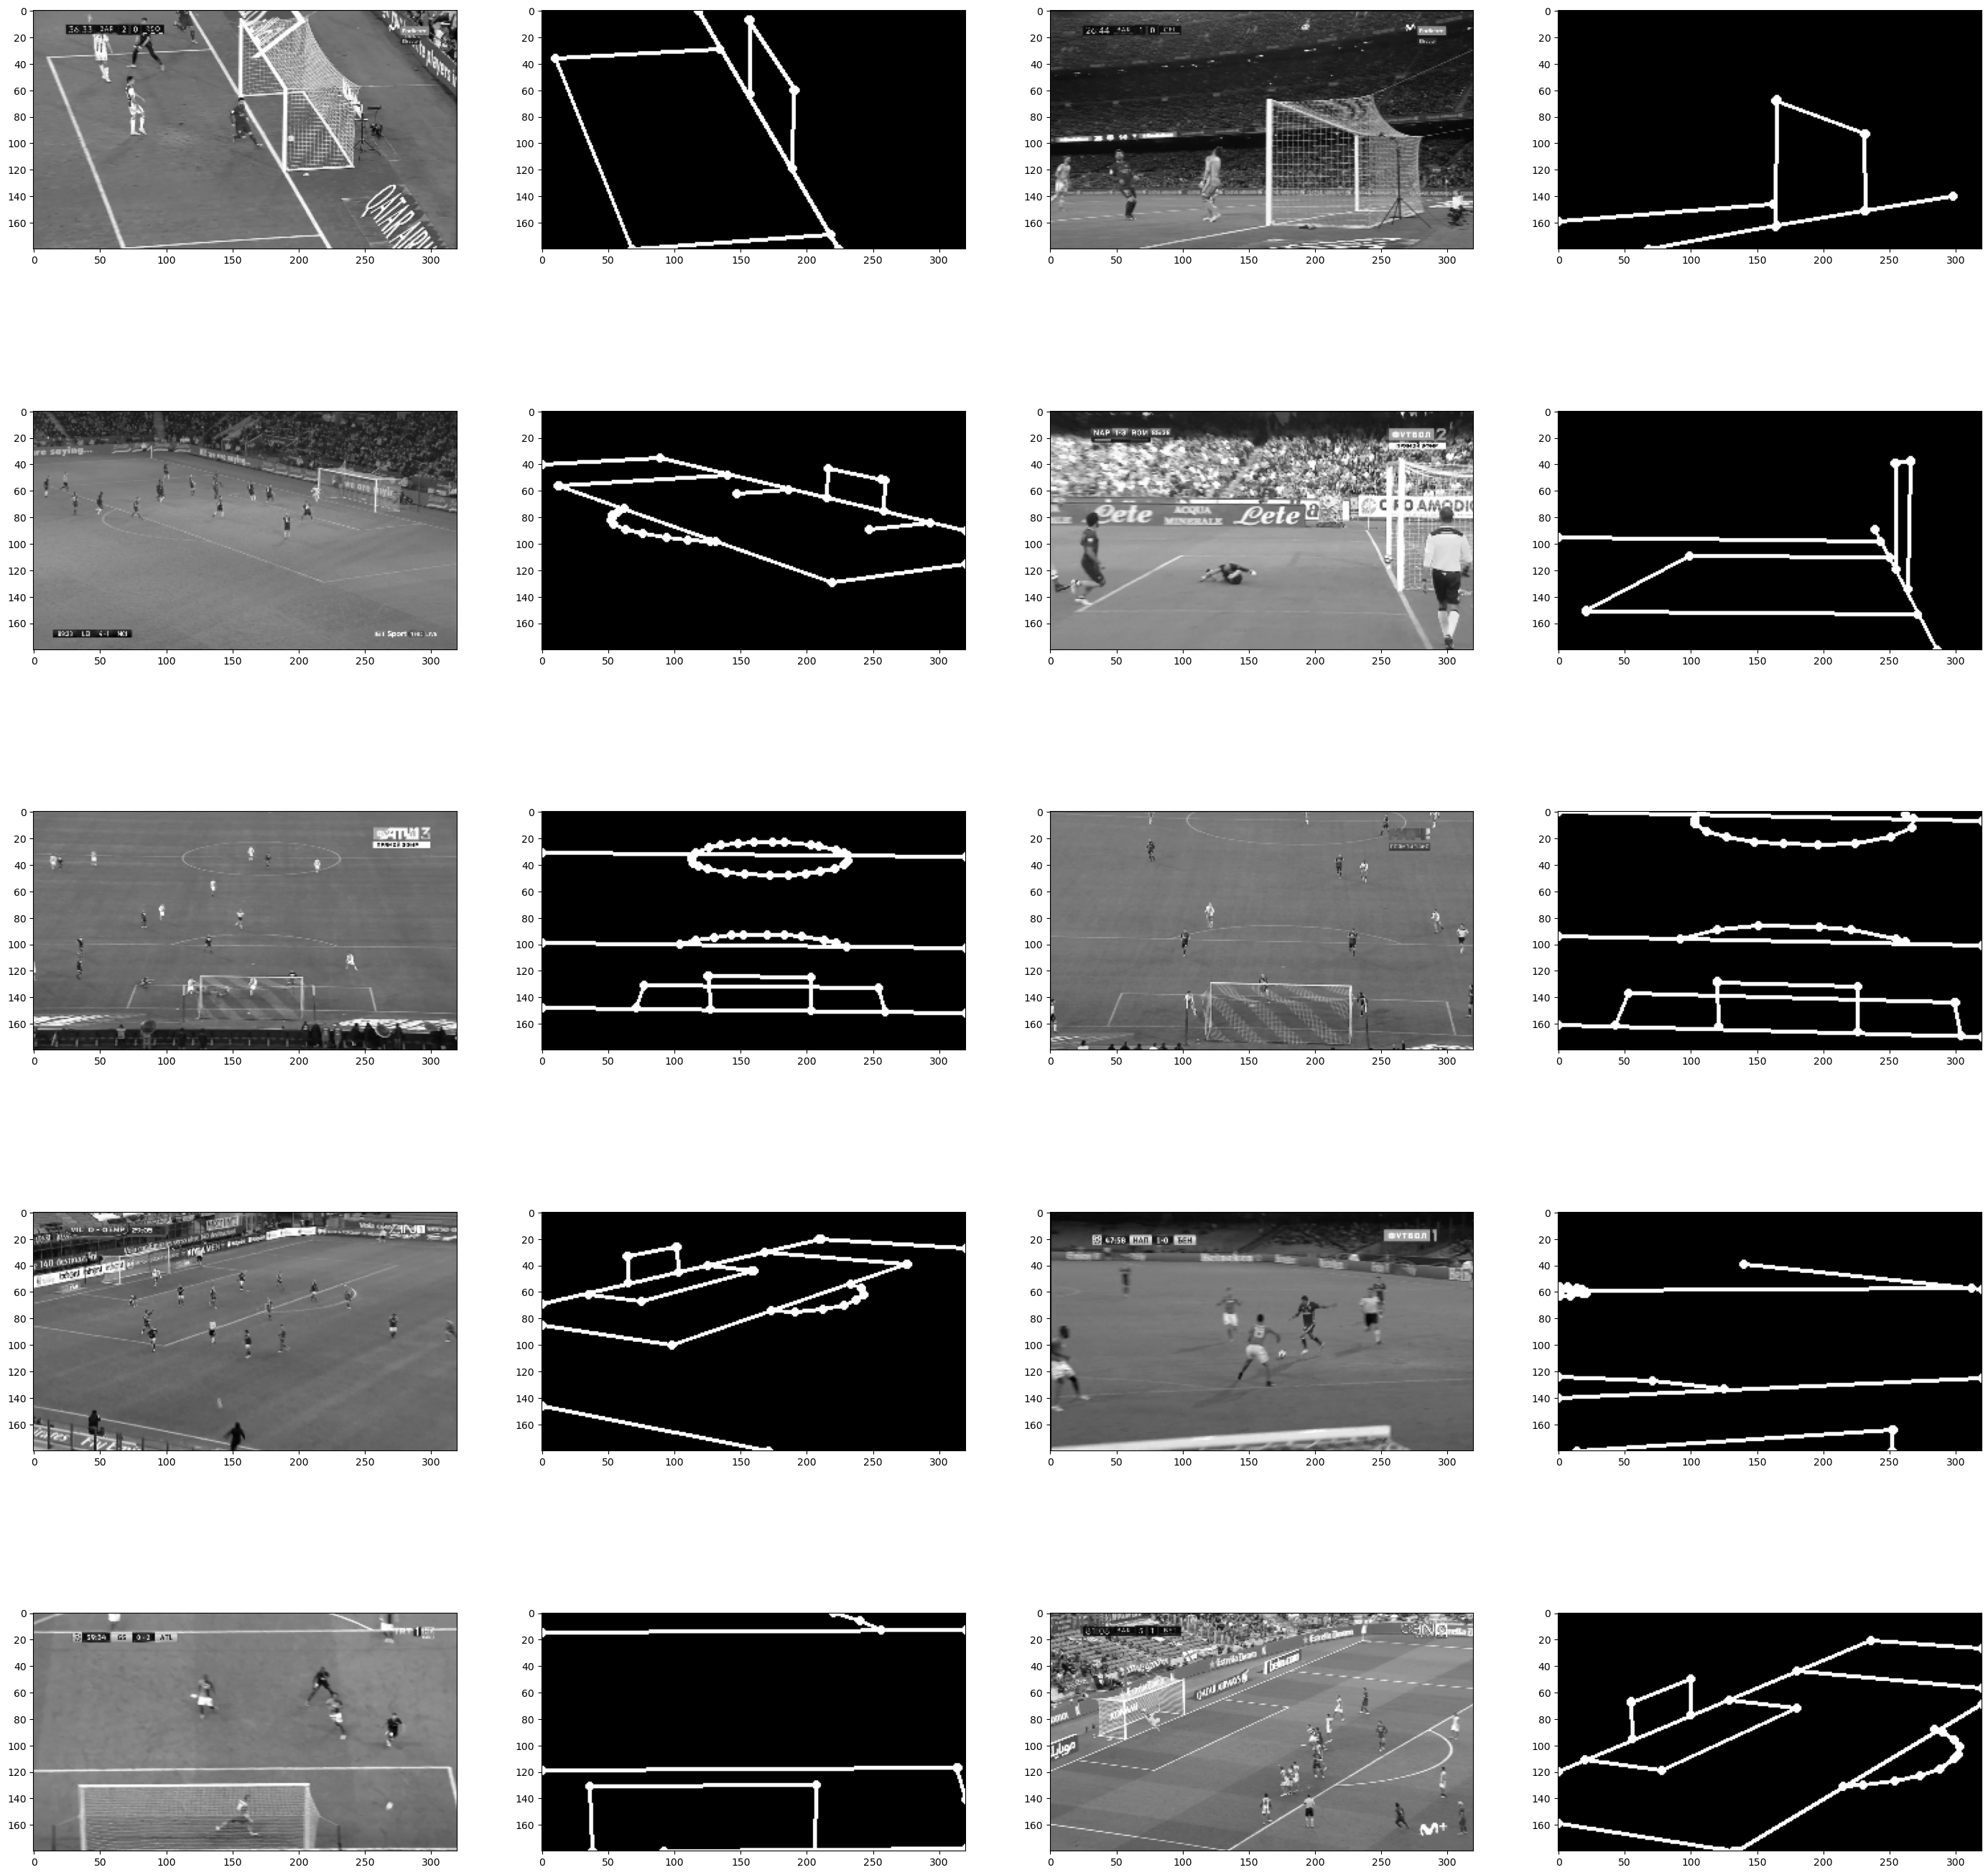

In [3]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(35, 35))

for idx in range(0, len(axes.flat), 2):
    img, mask = masking_calibration_train_dataset[idx]
    axes.flat[idx].imshow(img, cmap='gray')
    axes.flat[idx + 1].imshow(mask, cmap='gray')

plt.show()

## UNet

https://arxiv.org/abs/2504.14131

In [4]:
DEVICE = torch.device('mps')
torch.mps.empty_cache()

torch.hub.load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization='bn')
unet_model = torch.load('../weights/experimental/251006-unet-model.pt').to(DEVICE)
unet_model.eval()

print(f'UNet model device: {next(unet_model.parameters()).device}')

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main
/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_49750/585717763.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this ex

UNet model device: mps:0


In [5]:
# Choice of the loss function: https://arxiv.org/pdf/2312.05391
class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        pred_comp = 1 - pred
        target_comp = 1 - target
        return 1 - (pred * target).sum() / (pred + target).sum() - (pred_comp * target_comp).sum() / (pred_comp + target_comp).sum()

In [6]:
# https://medium.com/@weidagang/learning-pytorch-the-basic-program-structure-ed5723118b67

n_epochs = 16    # number of epochs to run
batch_size = 8   # size of each batch

train_dataloader = DataLoader(masking_calibration_train_dataset, batch_size=batch_size, shuffle=False)
valid_dataloader = DataLoader(masking_calibration_valid_dataset, batch_size=batch_size, shuffle=False)
optimiser = optim.Adam(unet_model.parameters(), lr=0.001)

loss_fn = DiceLoss().to(DEVICE)  # binary cross entropy

In [7]:
EPSILON = 1e-8
def per_image_normalisation(imgs):                      
    # img: [N x H x W]
    x_min = imgs.amin(dim=(1, 2), keepdim=True)
    x_max = imgs.amax(dim=(1, 2), keepdim=True)
    return (imgs - x_min) / (x_max - x_min + EPSILON)

16it [00:14,  1.07it/s]
0it [00:00, ?it/s]/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_49750/849449962.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
8it [00:02,  3.01it/s]



Epoch: 1, Test Loss: 0.2192



16it [00:12,  1.25it/s]
8it [00:02,  3.11it/s]



Epoch: 2, Test Loss: 0.2202



16it [00:12,  1.27it/s]
8it [00:02,  3.15it/s]


...


Epoch: 14, Test Loss: 0.2147



16it [00:12,  1.28it/s]
8it [00:02,  3.10it/s]



Epoch: 15, Test Loss: 0.2101



16it [00:12,  1.25it/s]
8it [00:02,  3.02it/s]



Epoch: 16, Test Loss: 0.1622



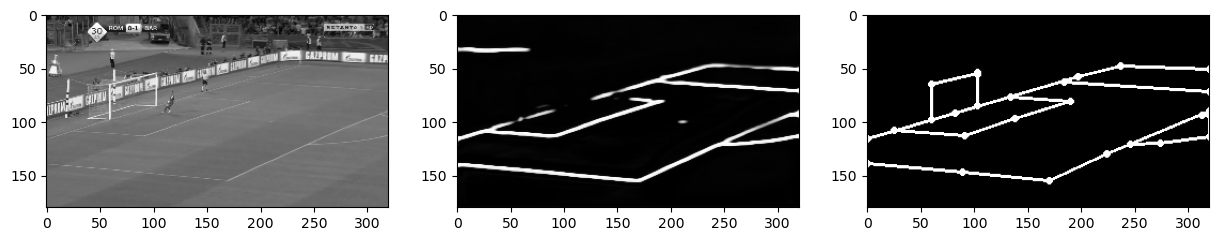

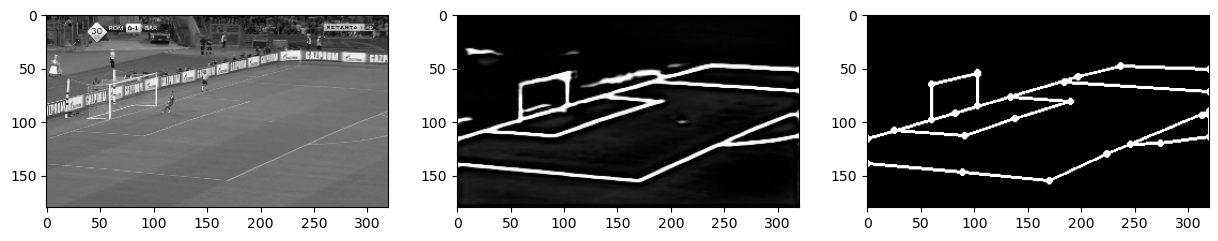

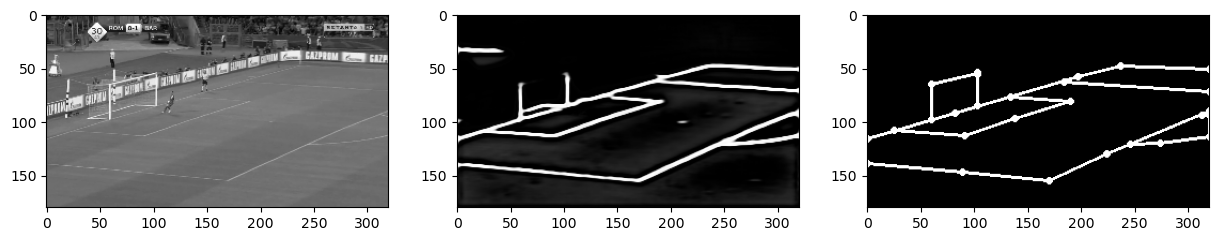

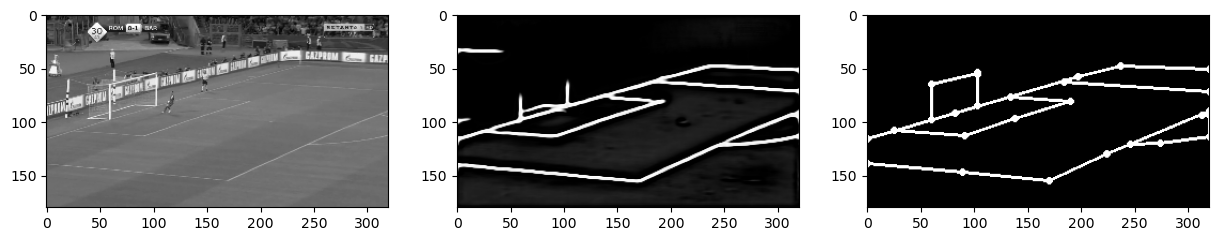

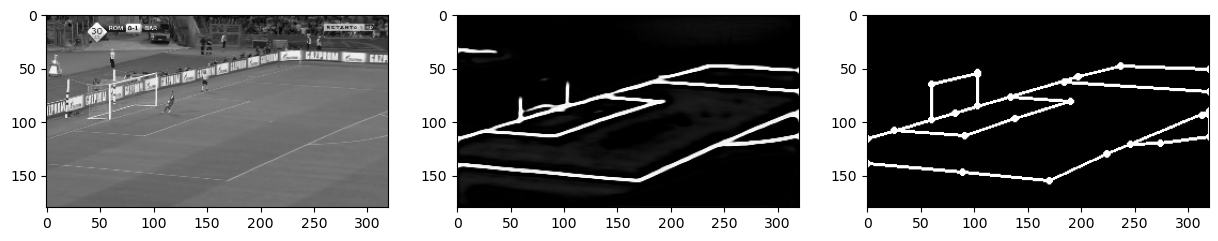

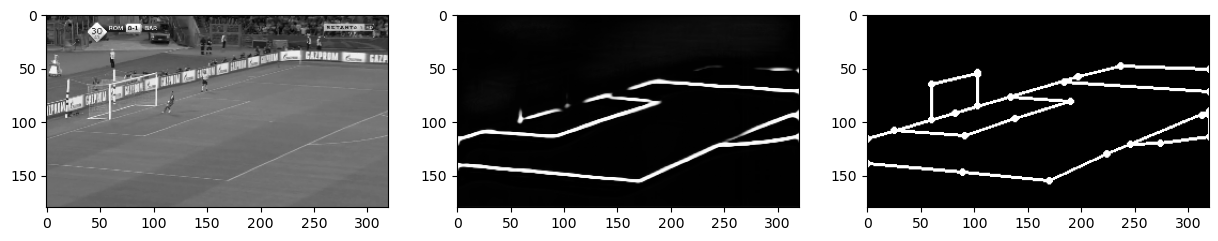

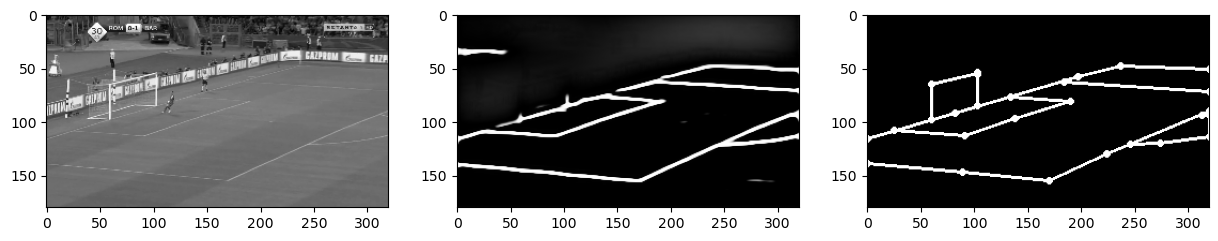

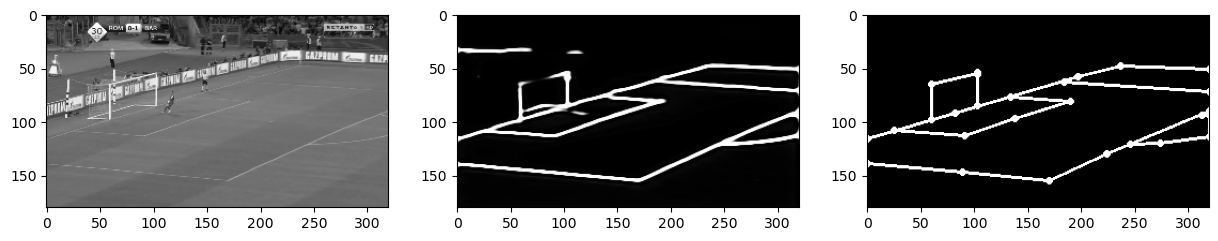

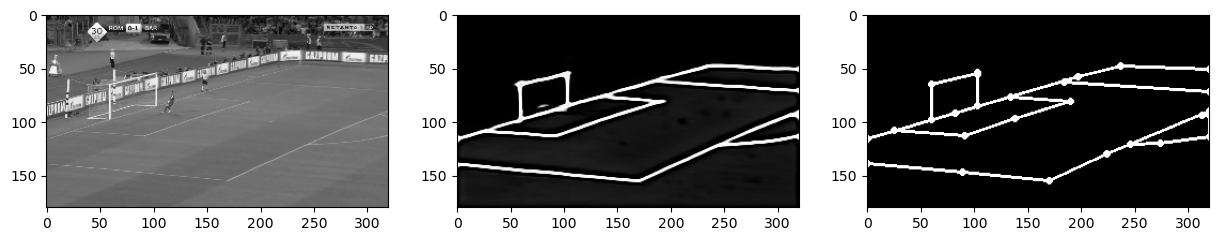

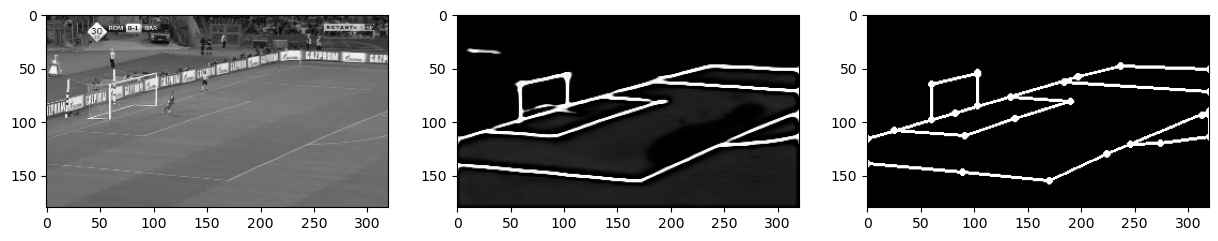

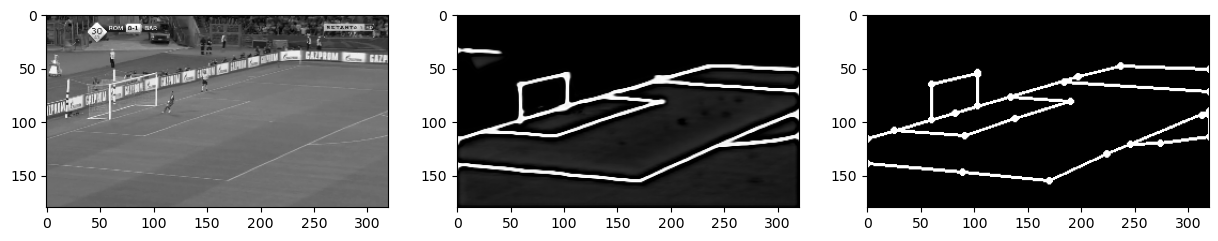

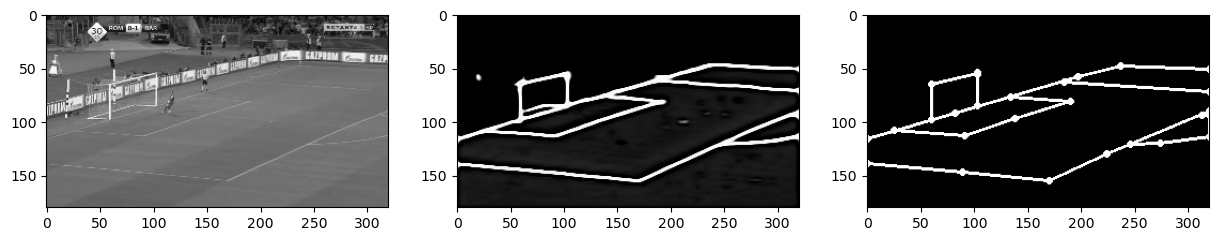

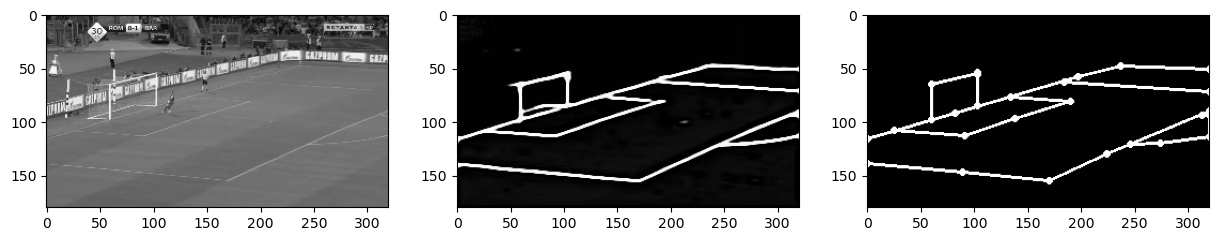

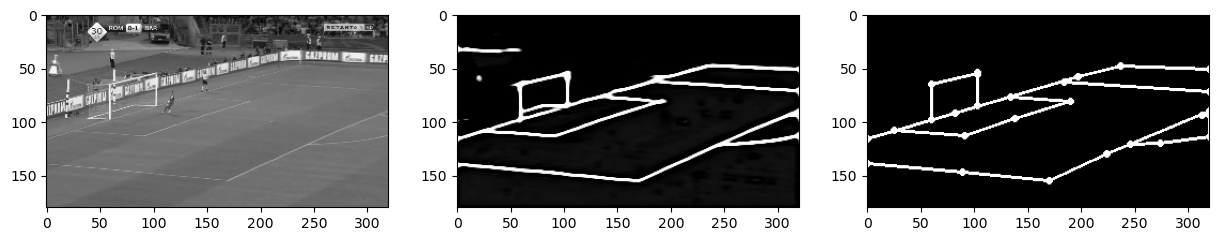

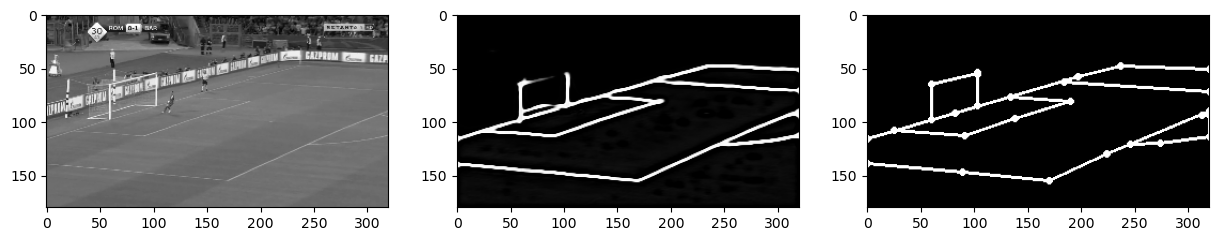

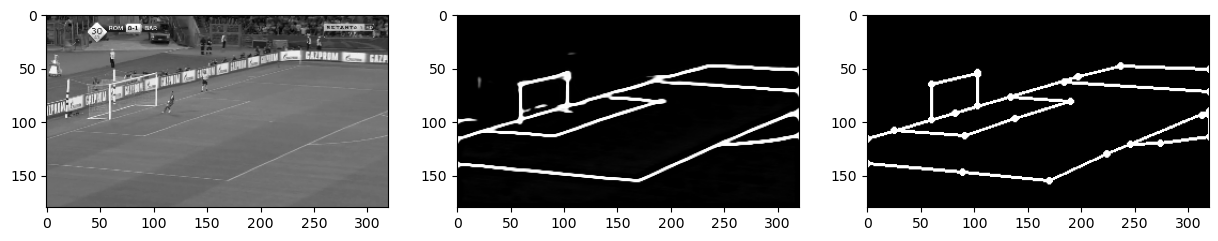

In [8]:
losses = []

for epoch in range(n_epochs):                                       
    unet_model.train()                                                  # Set the model to training mode
    for batch_idx, (img, mask) in tqdm(enumerate(train_dataloader)):    # Iterate over batches of data
        # img:  [(N) x 180 (H) x 320 (W)]
        # mask: [(N) x 180 (H) x 320 (W)]

        img = img.float().unsqueeze(1).to(DEVICE)
        mask = mask.float().unsqueeze(1).to(DEVICE)

        optimiser.zero_grad()                                           # Clear gradients from the previous iteration
        out_mask = unet_model(img)                                      # Forward pass through the model
        out_mask = per_image_normalisation(out_mask)

        loss = loss_fn(out_mask, mask)                                  # Calculate the loss
        loss.backward()                                                 # Compute gradients (backpropagation)
        optimiser.step()                                                # Update model parameters

    unet_model.eval()                                                   # Set the model to evaluation mode 
    test_loss = 0
    with torch.no_grad():                                               # Disable gradient calculations for efficiency
        for batch_idx, (img, mask) in tqdm(enumerate(valid_dataloader)): # Iterate over test data
            img = img.float().unsqueeze(1).to(DEVICE)
            mask = mask.float().unsqueeze(1).to(DEVICE)
            out_mask = unet_model(img)  
            out_mask = per_image_normalisation(out_mask)
            test_loss += loss_fn(out_mask, mask).item() * len(img)      # Accumulate test loss 

            if batch_idx == 0:
                fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
                def img_convert(img):
                    return img.permute((1, 2, 0)).cpu().numpy()

                axes.flat[0].imshow(img_convert(img[2]), cmap='gray')
                axes.flat[1].imshow(img_convert(out_mask[2]), cmap='gray')
                axes.flat[2].imshow(img_convert(mask[2]), cmap='gray')
                fig.show()

    test_loss /= len(valid_dataloader.dataset)                           # Calculate average test loss
    losses.append(test_loss)

    print('\nEpoch: {}, Test Loss: {:.4f}\n'.format(epoch + 1, test_loss))

torch.Size([8, 1, 180, 320])


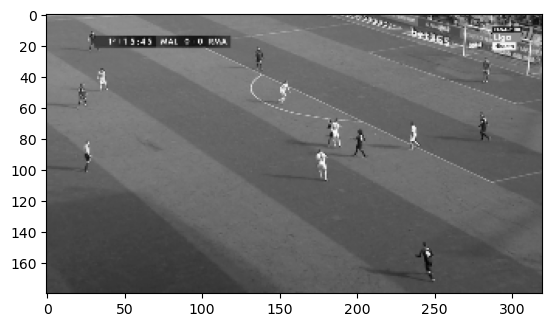

In [9]:
print(img.shape)
plt.imshow(img[0][0].cpu(), cmap='gray')

In [10]:
test_dataloader = DataLoader(masking_calibration_test_dataset, batch_size=batch_size, shuffle=False)
img, mask = next(iter(test_dataloader))
img = img.float().unsqueeze(1).to(DEVICE)
mask = mask.float().unsqueeze(1).to(DEVICE)

unet_model.eval().to(DEVICE)
out_mask = unet_model(img)
out_mask = per_image_normalisation(out_mask)
print(f'img.shape = {img.shape}, out_mask.shape = {out_mask.shape}, mask.shape = {mask.shape}')

img.shape = torch.Size([8, 1, 180, 320]), out_mask.shape = torch.Size([8, 1, 180, 320]), mask.shape = torch.Size([8, 1, 180, 320])


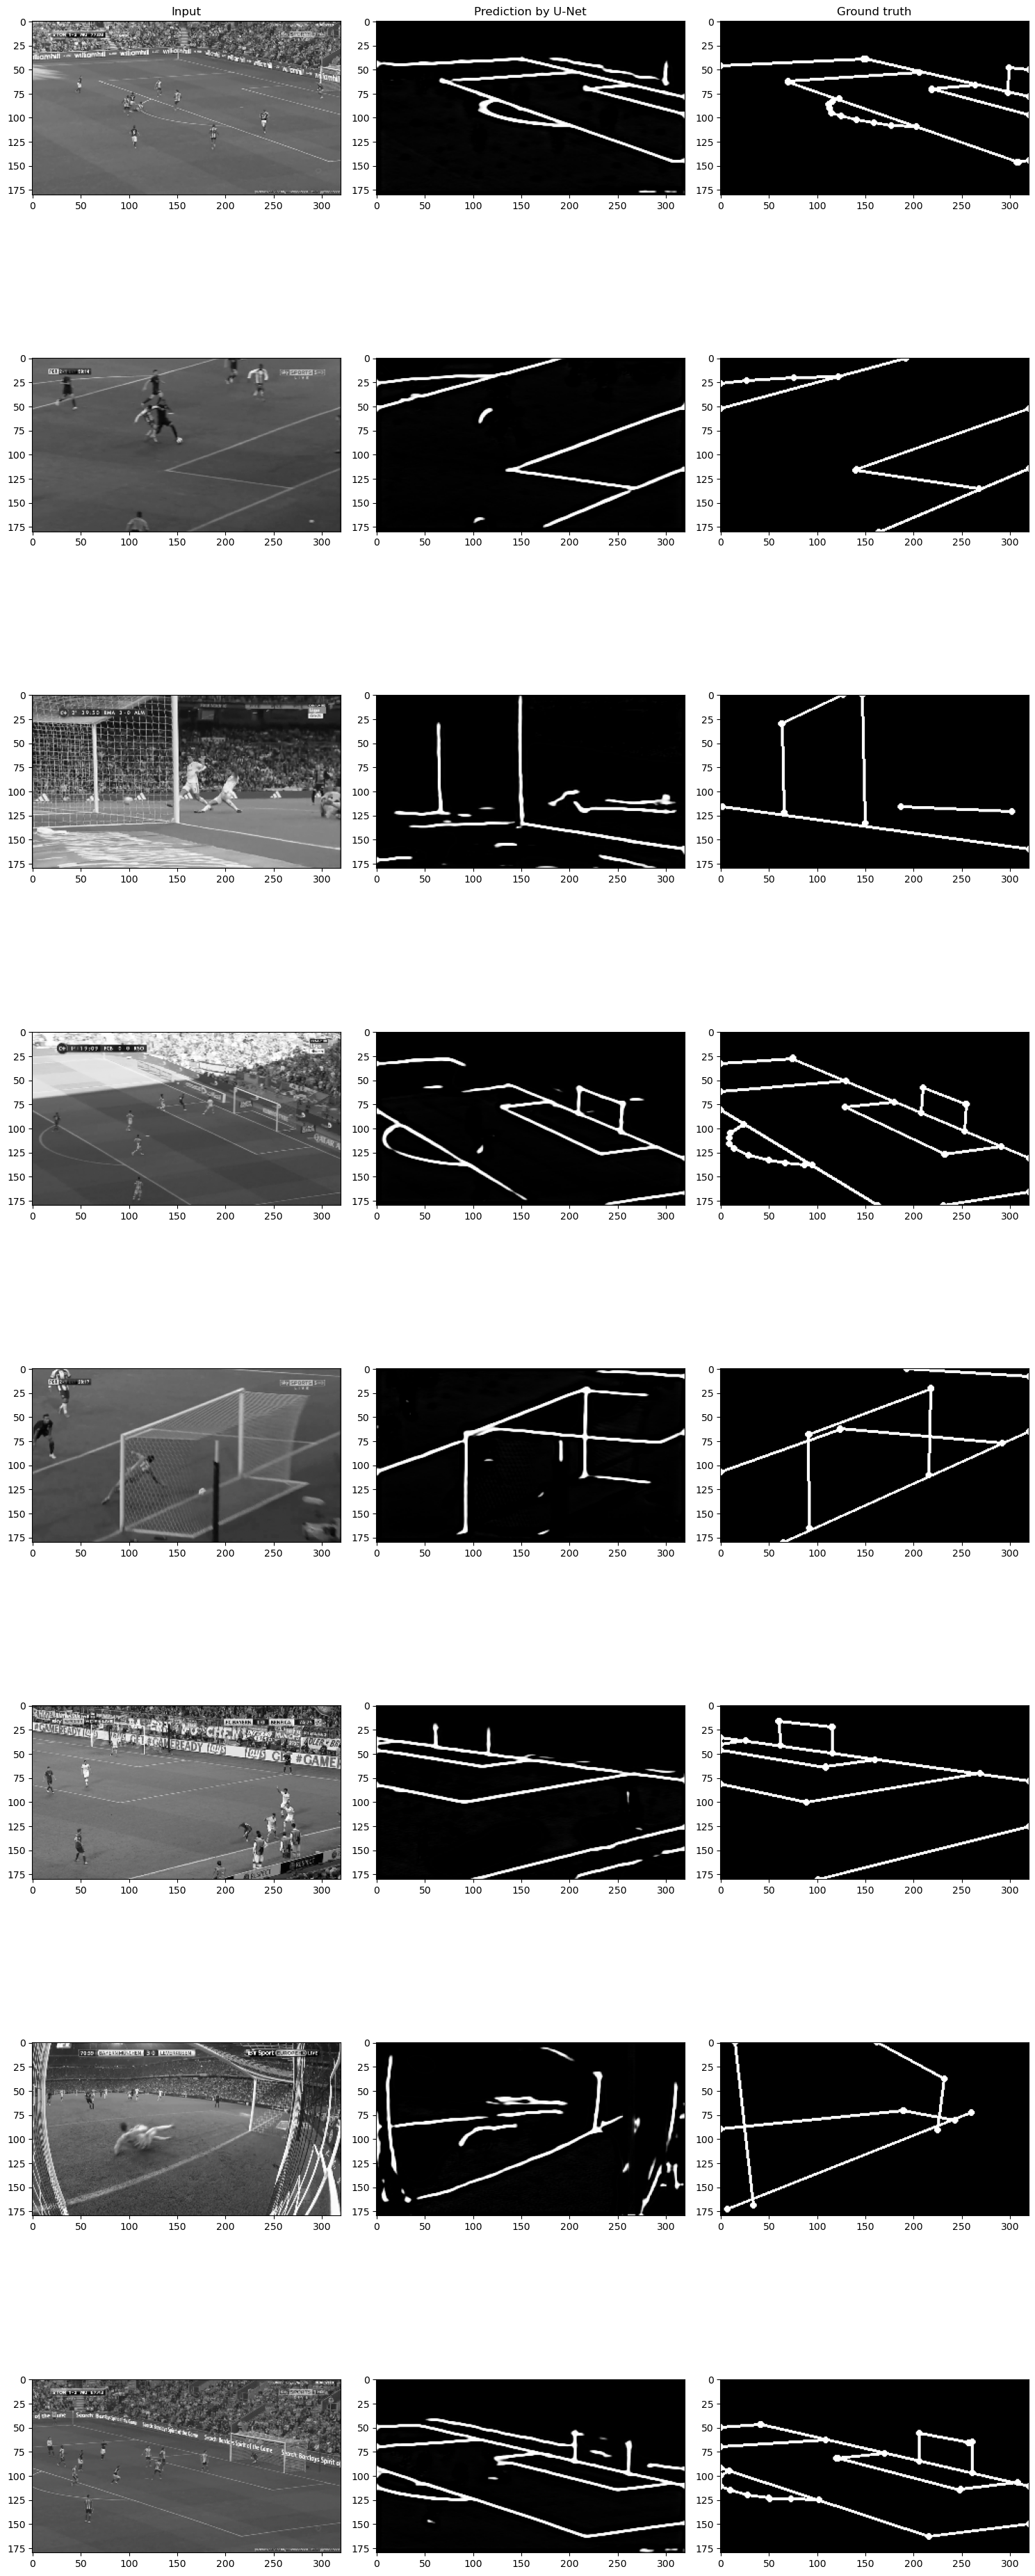

In [11]:
fig, axes = plt.subplots(nrows=batch_size, ncols=3, figsize=(15, 40))
def img_convert(img):
    return img.permute((1, 2, 0)).cpu().detach().numpy()

for idx in range(batch_size):
    axes[idx, 0].imshow(img_convert(img[idx]), cmap='gray')
    axes[idx, 1].imshow(img_convert(out_mask[idx]), cmap='gray')
    axes[idx, 2].imshow(img_convert(mask[idx]), cmap='gray')

axes[0, 0].set_title('Input')
axes[0, 1].set_title('Prediction by U-Net')
axes[0, 2].set_title('Ground truth')

fig.tight_layout()
plt.show()

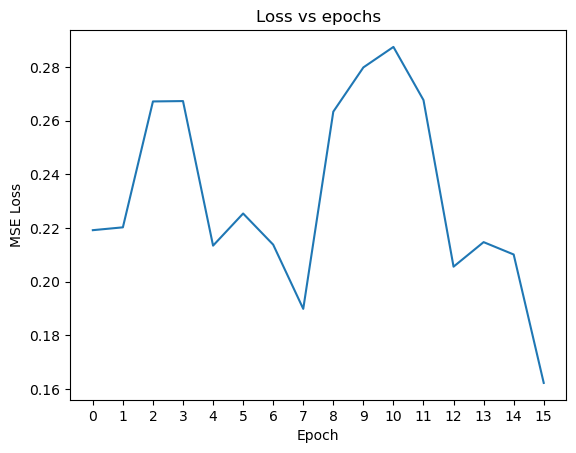

In [12]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.xticks(range(len(losses)))
plt.title('Loss vs epochs')
plt.show()

In [13]:
torch.save(unet_model, '../weights/experimental/251102-unet-model.pt')